## Imports, database and tables setup

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# For time series analysis
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression

# For interactive visualizations
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import psycopg2
from psycopg2 import sql

import os
from pathlib import Path

In [2]:
class RacingDataLoader:
    """Load and preprocess data from PostgreSQL database"""
    
    def __init__(self, host, database, user, password, port=5432):
        self.host = host
        self.database = database
        self.user = user
        self.password = password
        self.port = port
        self.conn = None
        
    def connect(self):
        """Connect to PostgreSQL database"""
        self.conn = psycopg2.connect(
            host=self.host,
            database=self.database,
            user=self.user,
            password=self.password,
            port=self.port
        )
        print(f"Connected to PostgreSQL database: {self.database}")
        
    def explore_schema(self):
        """Discover all tables and their columns"""
        print("="*80)
        print("DATABASE SCHEMA EXPLORATION")
        print("="*80)
        
        # Get all tables
        tables_query = """
            SELECT table_name 
            FROM information_schema.tables 
            WHERE table_schema = 'public' 
            ORDER BY table_name;
        """
        tables_df = pd.read_sql_query(tables_query, self.conn)
        print(f"\nFound {len(tables_df)} tables:")
        print(tables_df['table_name'].tolist())
        
        schema_info = {}
        
        # Get columns for each table
        for table_name in tables_df['table_name']:
            print(f"\n{'='*80}")
            print(f"TABLE: {table_name.upper()}")
            print(f"{'='*80}")
            
            columns_query = """
                SELECT column_name, data_type, is_nullable
                FROM information_schema.columns
                WHERE table_schema = 'public' AND table_name = %s
                ORDER BY ordinal_position;
            """
            columns_df = pd.read_sql_query(columns_query, self.conn, params=[table_name])
            print(f"Columns ({len(columns_df)}):")
            print(columns_df.to_string(index=False))
            
            # Get sample data - FIX: Use cursor instead
            cursor = self.conn.cursor()
            safe_table_name = sql.Identifier(table_name)
            sample_query = sql.SQL("SELECT * FROM {} LIMIT 3").format(safe_table_name)
            cursor.execute(sample_query)
            sample_df = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in cursor.description])
            cursor.close()
            
            print(f"\nSample data (first 3 rows):")
            display(sample_df)
            
            # Get row count - FIX: Use cursor instead
            cursor = self.conn.cursor()
            count_query = sql.SQL("SELECT COUNT(*) FROM {}").format(safe_table_name)
            cursor.execute(count_query)
            row_count = cursor.fetchone()[0]
            cursor.close()
            print(f"Total rows: {row_count}")
            
            schema_info[table_name] = {
                'columns': columns_df['column_name'].tolist(),
                'row_count': row_count,
                'sample': sample_df
            }
        
        return schema_info
    
    def load_all_tables(self):
        """Load all relevant tables from database"""
        # First explore schema
        schema_info = self.explore_schema()
        
        # Load tables into DataFrames - FIX: Use cursor
        tables = {}
        for table_name in schema_info.keys():
            cursor = self.conn.cursor()
            safe_table_name = sql.Identifier(table_name)
            query = sql.SQL("SELECT * FROM {}").format(safe_table_name)
            cursor.execute(query)
            table_df = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in cursor.description])
            cursor.close()
            tables[table_name] = table_df
            print(f"Loaded {table_name}: {tables[table_name].shape}")
        
        return tables, schema_info
    
    def close(self):
        if self.conn:
            self.conn.close()
            print("Database connection closed")
# Usage - Update with your pgAdmin credentials
db_config = {
    'host': 'localhost',           # or your server address
    'database': 'tad',   # your database name
    'user': 'postgres',            # your username
    'password': 'EF3TNdWibwzyAn35pW72',   # your password
    'port': 5432
}

loader = RacingDataLoader(**db_config)
loader.connect()
data, schema_info = loader.load_all_tables()

Connected to PostgreSQL database: tad
DATABASE SCHEMA EXPLORATION

Found 6 tables:
['car_data', 'drivers', 'laps', 'pits', 'stints', 'weather_sessions']

TABLE: CAR_DATA
Columns (10):
  column_name         data_type is_nullable
         date character varying         YES
  session_key            bigint         YES
        brake            bigint         YES
       n_gear            bigint         YES
driver_number            bigint         YES
  meeting_key            bigint         YES
          drs            bigint         YES
     throttle            bigint         YES
        speed            bigint         YES
          rpm            bigint         YES

Sample data (first 3 rows):


,date,session_key,brake,n_gear,driver_number,meeting_key,drs,throttle,speed,rpm
0,2023-08-25T10:15:02.924000+00:00,9142,0,0,39,1217,8,0,0,4215
1,2023-08-25T10:15:03.164000+00:00,9142,0,0,39,1217,8,0,0,4068
2,2023-08-25T10:15:03.324000+00:00,9142,0,0,39,1217,8,0,0,4086


Total rows: 792052

TABLE: DRIVERS
Columns (8):
  column_name         data_type is_nullable
           id            bigint         YES
  meeting_key            bigint         YES
  session_key            bigint         YES
driver_number            bigint         YES
    full_name character varying         YES
 name_acronym character varying         YES
    team_name character varying         YES
         year            bigint         YES

Sample data (first 3 rows):


,id,meeting_key,session_key,driver_number,full_name,name_acronym,team_name,year
0,0,1140,7763,1,Max VERSTAPPEN,VER,Red Bull Racing,2023
1,1,1140,7763,2,Logan SARGEANT,SAR,Williams,2023
2,2,1140,7763,4,Lando NORRIS,NOR,McLaren,2023


Total rows: 276

TABLE: LAPS
Columns (17):
      column_name         data_type is_nullable
               id            bigint         YES
      meeting_key            bigint         YES
      session_key            bigint         YES
    driver_number            bigint         YES
       lap_number            bigint         YES
       date_start character varying         YES
duration_sector_1           numeric         YES
duration_sector_2           numeric         YES
duration_sector_3           numeric         YES
         i1_speed           numeric         YES
         i2_speed           numeric         YES
   is_pit_out_lap           boolean         YES
     lap_duration           numeric         YES
segments_sector_1 character varying         YES
segments_sector_2 character varying         YES
segments_sector_3 character varying         YES
         st_speed           numeric         YES

Sample data (first 3 rows):


...

Total rows: 1816

TABLE: STINTS
Columns (9):
      column_name         data_type is_nullable
               id            bigint         YES
      meeting_key            bigint         YES
      session_key            bigint         YES
     stint_number            bigint         YES
    driver_number            bigint         YES
        lap_start           numeric         YES
          lap_end           numeric         YES
         compound character varying         YES
tyre_age_at_start           numeric         YES

Sample data (first 3 rows):


,id,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
0,0,1140,7763,1,14,1.0,3.0,MEDIUM,0.0
1,1,1140,7763,1,24,1.0,3.0,MEDIUM,10.0
2,2,1140,7763,1,4,1.0,2.0,MEDIUM,7.0


Total rows: 31227

TABLE: WEATHER_SESSIONS
Columns (15):
      column_name         data_type is_nullable
               id            bigint         YES
      meeting_key            bigint         YES
      session_key            bigint         YES
             year            bigint         YES
     country_name character varying         YES
     session_type character varying         YES
     session_name character varying         YES
         humidity           numeric         YES
         pressure           numeric         YES
         rainfall            bigint         YES
       wind_speed           numeric         YES
   wind_direction            bigint         YES
  air_temperature           numeric         YES
track_temperature           numeric         YES
air_temperature_1           numeric         YES

Sample data (first 3 rows):


,id,meeting_key,session_key,year,country_name,session_type,session_name,humidity,pressure,rainfall,wind_speed,wind_direction,air_temperature,track_temperature,air_temperature_1
0,0,1140,7763,2023,Bahrain,Practice,Day 2,49.0,1011.7,0,4.0,183,24.0,29.5,24.0
1,1,1140,7763,2023,Bahrain,Practice,Day 2,49.0,1011.7,0,5.0,192,23.9,29.6,23.9
2,2,1140,7763,2023,Bahrain,Practice,Day 2,50.0,1011.7,0,3.9,190,23.9,29.6,23.9


Total rows: 39311
Loaded car_data: (792052, 10)
Loaded drivers: (276, 8)
Loaded laps: (166511, 17)
Loaded pits: (1816, 8)
Loaded stints: (31227, 9)
Loaded weather_sessions: (39311, 15)


In [3]:
def identify_racing_tables(schema_info):
    """Identify tables and columns"""

    table_mapping = {
        'laps': 'laps',
        'pits': 'pits', 
        'drivers': 'drivers',
        'stints': 'stints',
        'weather': 'weather_sessions',
        'car_data': 'car_data'
    }
    
    column_mapping = {
        'laps': {
            'lap_number': 'lap_number',
            'time_ms': 'lap_duration',  # This is in SECONDS, not ms!
            'driver_id': 'driver_number',
            'race_id': 'session_key',  # Use session_key as race identifier
            'meeting_key': 'meeting_key',
            'position': None,  # Not in your schema
            'sector1': 'duration_sector_1',
            'sector2': 'duration_sector_2', 
            'sector3': 'duration_sector_3'
        },
        'pits': {
            'lap': 'lap_number',
            'duration_ms': 'pit_duration',  # Likely in seconds
            'driver_id': 'driver_number',
            'race_id': 'session_key',
            'meeting_key': 'meeting_key',
            'stop_number': None
        },
        'drivers': {
            'driver_id': 'driver_number',
            'driver_ref': 'name_acronym',
            'forename': 'full_name',  # Full name in one field
            'surname': None,
            'number': 'driver_number'
        },
        'stints': {
            'driver_id': 'driver_number',
            'race_id': 'session_key',
            'lap_start': 'lap_start',
            'lap_end': 'lap_end',
            'compound': 'compound',
            'tyre_age': 'tyre_age_at_start'
        }
    }
    
    print("="*80)
    print("COLUMN MAPPING FOR YOUR SCHEMA")
    print("="*80)
    
    for table, columns in column_mapping.items():
        print(f"\n{table.upper()}:")
        for col_key, col_name in columns.items():
            status = f"✓ {col_name}" if col_name else "✗ NOT AVAILABLE"
            print(f"  {col_key:20s} {status}")
    
    # IMPORTANT NOTES about your data:
    print("\n" + "="*80)
    print("⚠️  IMPORTANT DATA NOTES")
    print("="*80)
    print("""
    1. TIME UNITS: Your 'lap_duration' and 'pit_duration' appear to be in SECONDS 
       (e.g., 117.654), NOT milliseconds. We'll multiply by 1000 when needed.
    
    2. RACE IDENTIFIER: Use 'session_key' + 'meeting_key' together to uniquely 
       identify a race session (not just race_id).
    
    3. DRIVER IDENTIFIER: Use 'driver_number' (e.g., 1, 4, 44) as the driver key.
    
    4. SECTOR TIMES: Stored as 'duration_sector_1/2/3' in numeric format (seconds).
    
    5. NO POSITION COLUMN: Your laps table doesn't have position data. We'll 
       skip position-based analyses or derive from other sources.
    """)
    
    return table_mapping, column_mapping

# Run identification
table_mapping, column_mapping = identify_racing_tables(schema_info)

# Create easy access variables
LAPS_TABLE = table_mapping['laps']
PITS_TABLE = table_mapping['pits']
DRIVERS_TABLE = table_mapping['drivers']
STINTS_TABLE = table_mapping['stints']

print(f"\n✅ Using tables:")
print(f"  Laps: {LAPS_TABLE}")
print(f"  Pits: {PITS_TABLE}")
print(f"  Drivers: {DRIVERS_TABLE}")
print(f"  Stints: {STINTS_TABLE}")

COLUMN MAPPING FOR YOUR SCHEMA

LAPS:
  lap_number           ✓ lap_number
  time_ms              ✓ lap_duration
  driver_id            ✓ driver_number
  race_id              ✓ session_key
  meeting_key          ✓ meeting_key
  position             ✗ NOT AVAILABLE
  sector1              ✓ duration_sector_1
  sector2              ✓ duration_sector_2
  sector3              ✓ duration_sector_3

PITS:
  lap                  ✓ lap_number
  duration_ms          ✓ pit_duration
  driver_id            ✓ driver_number
  race_id              ✓ session_key
  meeting_key          ✓ meeting_key
  stop_number          ✗ NOT AVAILABLE

DRIVERS:
  driver_id            ✓ driver_number
  driver_ref           ✓ name_acronym
  forename             ✓ full_name
  surname              ✗ NOT AVAILABLE
  number               ✓ driver_number

STINTS:
  driver_id            ✓ driver_number
  race_id              ✓ session_key
  lap_start            ✓ lap_start
  lap_end              ✓ lap_end
  compound           

In [4]:
# Quick sanity check - run this after Cell 3
print("Sample lap data with your columns:")
sample = data['laps'][['driver_number', 'lap_number', 'lap_duration', 
                       'duration_sector_1', 'duration_sector_2', 'session_key']].head(5)
display(sample)

print(f"\nUnique drivers: {data['laps']['driver_number'].nunique()}")
print(f"Unique sessions: {data['laps']['session_key'].nunique()}")
print(f"Lap duration range: {data['laps']['lap_duration'].min():.2f}s - {data['laps']['lap_duration'].max():.2f}s")

# Get the directory where the Jupyter notebook is located
NOTEBOOK_DIR = Path.cwd()  # Works in JupyterLab/Notebook
# Alternative if above doesn't work:
# NOTEBOOK_DIR = Path(os.path.dirname(os.path.abspath('__file__')))

Sample lap data with your columns:


,driver_number,lap_number,lap_duration,duration_sector_1,duration_sector_2,session_key
0,14,2,117.654,32.848,52.939,7763
1,55,2,98.225,31.234,42.725,7763
2,24,2,116.672,35.235,49.319,7763
3,22,2,105.329,33.434,45.551,7763
4,31,2,99.582,32.336,42.895,7763



Unique drivers: 48
Unique sessions: 356
Lap duration range: 63.97s - 1129.70s


## Models: Speed degradation, pitstop optimizer and lap time prediciton

In [5]:
class SpeedDegradationAnalyzer:
    """Time-series regression for lap-by-lap speed degradation"""
    
    def __init__(self, laps_df, drivers_df, column_mapping, stints_df=None):
        self.laps_df = laps_df.copy()
        self.drivers_df = drivers_df.copy()
        self.stints_df = stints_df.copy() if stints_df is not None else None
        self.col_map = column_mapping['laps']
        self.driver_col_map = column_mapping['drivers']
        self.models = {}
        self.results = pd.DataFrame()  # Initialize empty
        
    def preprocess_data(self):
        """Prepare data using YOUR column names"""
        # Get actual column names
        lap_col = self.col_map['lap_number']  # 'lap_number'
        time_col = self.col_map['time_ms']    # 'lap_duration' (in SECONDS!)
        driver_col = self.col_map['driver_id']  # 'driver_number'
        session_col = self.col_map['race_id']   # 'session_key'
        meeting_col = self.col_map['meeting_key']
        
        # Merge with driver info
        if driver_col in self.laps_df.columns and self.driver_col_map['driver_id'] in self.drivers_df.columns:
            self.df = self.laps_df.merge(
                self.drivers_df[[self.driver_col_map['driver_id'], 
                                self.driver_col_map['driver_ref'],
                                self.driver_col_map['forename'],
                                'team_name']], 
                left_on=driver_col, 
                right_on=self.driver_col_map['driver_id'], 
                how='left'
            )
        else:
            self.df = self.laps_df.copy()
            
        # Convert to numeric
        self.df[lap_col] = pd.to_numeric(self.df[lap_col], errors='coerce')
        self.df[time_col] = pd.to_numeric(self.df[time_col], errors='coerce')
        
        # ⚠️ YOUR DATA: lap_duration is in SECONDS, convert to ms for consistency
        self.df['lap_time_ms'] = self.df[time_col] * 1000
        self.df['lap_time_sec'] = self.df[time_col]  # Keep seconds version too
        
        # Remove outliers (lap times < 60s or > 300s are likely errors)
        self.df = self.df[
            (self.df['lap_time_sec'] >= 60) & 
            (self.df['lap_time_sec'] <= 300)
        ]
        
        # Store column references
        self.lap_col = lap_col
        self.time_col = time_col
        self.driver_col = driver_col
        self.session_col = session_col
        self.meeting_col = meeting_col
        
        print(f"✓ Preprocessed {len(self.df)} lap records")
        print(f"  Time column: '{time_col}' (original unit: seconds)")
        print(f"  Driver column: '{driver_col}'")
        print(f"  Session identifier: '{session_col}' + '{meeting_col}'")
        
        return self
    
    def analyze_driver_degradation(self, driver_number=None, session_key=None, 
                                meeting_key=None, lap_range=None, use_stints=True):
        """
        Analyze speed degradation PER STINT (resets on tire change)
        Handles dtype mismatches and interval matching safely.
        """
        df_filtered = self.df.copy()
        
        # Apply basic filters
        if driver_number is not None:
            df_filtered = df_filtered[df_filtered[self.driver_col] == driver_number]
        if session_key is not None:
            df_filtered = df_filtered[df_filtered[self.session_col] == session_key]
        if meeting_key is not None:
            df_filtered = df_filtered[df_filtered[self.meeting_col] == meeting_key]
        if lap_range is not None:
            df_filtered = df_filtered[
                (df_filtered[self.lap_col] >= lap_range[0]) & 
                (df_filtered[self.lap_col] <= lap_range[1])
            ]
        
        # ⚠️ STINT-AWARE GROUPING WITH SAFE TYPE HANDLING
        if use_stints and self.stints_df is not None:
            # 1. Standardize dtypes to prevent merge errors
            stints_clean = self.stints_df.copy()
            for col in ['driver_number', 'session_key', 'meeting_key', 'lap_start', 'lap_end']:
                stints_clean[col] = pd.to_numeric(stints_clean[col], errors='coerce')
                
            laps_clean = df_filtered.copy()
            for col in ['driver_number', 'session_key', 'meeting_key', 'lap_number']:
                laps_clean[col] = pd.to_numeric(laps_clean[col], errors='coerce')
                
            # 2. Merge on exact driver/session/meeting keys
            merged = laps_clean.merge(
                stints_clean[['driver_number', 'session_key', 'meeting_key', 'lap_start', 'lap_end', 'stint_number', 'compound']],
                on=['driver_number', 'session_key', 'meeting_key'],
                how='left'
            )
            
            # 3. Filter to laps that actually fall within the stint range
            in_range = (merged['lap_number'] >= merged['lap_start']) & (merged['lap_number'] <= merged['lap_end'])
            matched_stints = merged[in_range].drop_duplicates(
                subset=['driver_number', 'session_key', 'meeting_key', 'lap_number'], keep='first'
            )
            
            # 4. Map stint info back using multi-index (avoids cross-join issues)
            match_index = matched_stints.set_index(['driver_number', 'session_key', 'meeting_key', 'lap_number'])
            df_filtered = df_filtered.set_index(['driver_number', 'session_key', 'meeting_key', 'lap_number'])
            df_filtered['stint_number'] = match_index['stint_number']
            df_filtered['compound'] = match_index['compound']
            df_filtered = df_filtered.reset_index()
            
            # Create unique stint identifier
            df_filtered['stint_id'] = df_filtered['driver_number'].astype(str) + '_' + \
                                      df_filtered['session_key'].astype(str) + '_' + \
                                      df_filtered['stint_number'].astype(str)
            group_cols = ['driver_number', 'session_key', 'meeting_key', 'stint_id']
        else:
            group_cols = ['driver_number', 'session_key', 'meeting_key']
        
        # Group and run regression per stint
        grouped = df_filtered.groupby(group_cols)
        degradation_results = []
        
        for name, group in grouped:
            group = group.sort_values(self.lap_col)
            if len(group) < 4:  # Need minimum 4 laps for meaningful regression
                continue
                
            X = group[self.lap_col].values.reshape(-1, 1)
            y = group['lap_time_sec'].values
            
            model = LinearRegression()
            model.fit(X, y)
            
            y_pred = model.predict(X)
            r2 = r2_score(y, y_pred)
            
            # Filter out noise/poor fits
            if r2 < -0.1:
                continue
                
            degradation_results.append({
                'driver_number': name[0],
                'session_key': name[1],
                'meeting_key': name[2],
                'stint_id': name[3] if len(name) > 3 else None,
                'degradation_rate_sec_per_lap': model.coef_[0],
                'baseline_lap_time': model.intercept_,
                'r2_score': r2,
                'avg_lap_time_sec': y.mean(),
                'num_laps': len(group),
                'tire_compound': group['compound'].iloc[0] if 'compound' in group.columns else None
            })
        
        self.results = pd.DataFrame(degradation_results)
        return self.results
    
    def _assign_stints_by_overlap(self, laps_df, stints_df):
        """Helper: assign stint when exact lap match fails"""
        def find_stint(row):
            mask = (
                (stints_df['driver_number'] == row[self.driver_col]) &
                (stints_df['session_key'] == row[self.session_col]) &
                (stints_df['meeting_key'] == row[self.meeting_col]) &
                (stints_df['lap_start'] <= row[self.lap_col]) &
                (stints_df['lap_end'] >= row[self.lap_col])
            )
            match = stints_df[mask].iloc[0] if mask.any() else None
            return match['stint_number'] if match is not None else None
        
        laps_df['stint_number'] = laps_df.apply(find_stint, axis=1)
        return laps_df

# ============================================================================
# UPDATED USAGE: Multi-Driver Stint Analysis with Verification
# ============================================================================
analyzer = SpeedDegradationAnalyzer(
    data[LAPS_TABLE], 
    data[DRIVERS_TABLE], 
    column_mapping,
    stints_df=data.get('stints')
)
analyzer.preprocess_data()

unique_sessions = data['laps'][['driver_number', 'session_key', 'meeting_key']].dropna().drop_duplicates()
top_n = 10
driver_lap_counts = data['laps'].groupby('driver_number').size().sort_values(ascending=False).head(top_n)

print(f"\n Processing top {top_n} drivers...")
all_results = []
drivers_with_data = []

for driver_num in driver_lap_counts.index:
    driver_sessions = unique_sessions[unique_sessions['driver_number'] == driver_num]
    session_count = 0
    for _, session in driver_sessions.iterrows():
        results = analyzer.analyze_driver_degradation(
            driver_number=driver_num,
            session_key=session['session_key'],
            meeting_key=session['meeting_key'],
            lap_range=(1, 60)
        )
        if not results.empty:
            all_results.append(results)
            session_count += len(results)
    
    if session_count > 0:
        drivers_with_data.append(driver_num)
        print(f"  ✅ Driver #{driver_num}: {session_count} valid stints")

if all_results:
    analyzer.results = pd.concat(all_results, ignore_index=True)
    print(f"\n Final Dataset: {len(analyzer.results)} stints across {len(drivers_with_data)} drivers")
    print(f"   Drivers included: {drivers_with_data}")
    display(analyzer.results.head(5))
else:
    print("⚠️ No valid stints found. Check R² thresholds or stint mapping.")

# Optional: Visualize (only if you added the method above)
# analyzer.visualize_degradation(driver_number=None)

# Example: Single-driver query for testing
single_result = analyzer.analyze_driver_degradation(
    driver_number=1,
    session_key=7763,
    meeting_key=1140,
    lap_range=(1, 50)
)
if not single_result.empty:
    print(f"\n🔍 Example: Driver #1, Session 7763")
    print(f"   Degradation rate: {single_result['degradation_rate_sec_per_lap'].iloc[0]:.3f} sec/lap")
    print(f"   Baseline lap time: {single_result['baseline_lap_time'].iloc[0]:.2f} sec")
    print(f"   Model R²: {single_result['r2_score'].iloc[0]:.3f}")

    def visualize_degradation(self, driver_number=None, max_drivers=5):
        """Simple matplotlib visualization of degradation trends"""
        import matplotlib.pyplot as plt
        
        if self.results.empty:
            print("⚠️ No degradation results to visualize. Run analyze_driver_degradation() first.")
            return None
            
        # Filter results
        df_viz = self.results.copy()
        if driver_number is not None:
            df_viz = df_viz[df_viz['driver_number'] == driver_number]
        
        if df_viz.empty:
            print(f"⚠️ No results for driver #{driver_number}")
            return None
            
        # Show top N drivers by session count
        if driver_number is None:
            top_drivers = df_viz.groupby('driver_number').size().sort_values(ascending=False).head(max_drivers).index
            df_viz = df_viz[df_viz['driver_number'].isin(top_drivers)]
        
        fig, ax = plt.subplots(figsize=(10, 6))
        x_laps = np.arange(1, 61)  # First 60 laps
        
        colors = plt.cm.tab10(np.linspace(0, 1, df_viz['driver_number'].nunique()))
        for (driver, session, meeting), group in df_viz.groupby(['driver_number', 'session_key', 'meeting_key']):
            row = group.iloc[0]
            y_trend = row['baseline_lap_time'] + row['degradation_rate_sec_per_lap'] * x_laps
            label = f"#{row['driver_number']} (S:{session})"
            ax.plot(x_laps, y_trend, label=label, linewidth=1.5, alpha=0.8)
        
        ax.set_xlabel('Lap Number')
        ax.set_ylabel('Predicted Lap Time (seconds)')
        ax.set_title('Speed Degradation Trends')
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(1, 60)
        
        plt.tight_layout()
        plt.savefig(NOTEBOOK_DIR / 'speed_degradation_trends.png', dpi=300, bbox_inches='tight')
        print(f"✓ Saved degradation plot to 'speed_degradation_trends.png'")
        plt.show()
        
        return fig

✓ Preprocessed 1136936 lap records
  Time column: 'lap_duration' (original unit: seconds)
  Driver column: 'driver_number'
  Session identifier: 'session_key' + 'meeting_key'

 Processing top 10 drivers...
  ✅ Driver #63: 1379 valid stints
  ✅ Driver #16: 1380 valid stints
  ✅ Driver #55: 1356 valid stints
  ✅ Driver #4: 1307 valid stints
  ✅ Driver #81: 1327 valid stints
  ✅ Driver #44: 1385 valid stints
  ✅ Driver #1: 1298 valid stints
  ✅ Driver #14: 1246 valid stints
  ✅ Driver #22: 1188 valid stints
  ✅ Driver #10: 1210 valid stints

 Final Dataset: 13076 stints across 10 drivers
   Drivers included: [63, 16, 55, 4, 81, 44, 1, 14, 22, 10]


,driver_number,session_key,meeting_key,stint_id,degradation_rate_sec_per_lap,baseline_lap_time,r2_score,avg_lap_time_sec,num_laps,tire_compound
0,63,7763,1140,63_7763_1,4.2810,89.933,1.000000,100.63550,12,MEDIUM
1,63,7763,1140,63_7763_2,5.8590,69.556,1.000000,101.78050,12,MEDIUM
2,63,7763,1140,63_7763_3,1.6475,94.151,0.010665,109.80225,24,MEDIUM
3,63,7763,1140,63_7763_4,24.9530,-228.969,1.000000,107.89650,12,HARD
4,63,7763,1140,63_7763_5,22.6910,-267.908,1.000000,106.49350,12,MEDIUM



🔍 Example: Driver #1, Session 7763
   Degradation rate: 17.273 sec/lap
   Baseline lap time: -46.32 sec
   Model R²: 1.000


✓ Preprocessed 3702 pit stop records
Pit Stop Strategy Clusters:


lap_number              pit_duration_sec  \
                           mean    std count             mean   
pit_strategy_cluster                                            
0                         39.63  11.06  1462            22.41   
1                         17.21   6.26  1450            23.54   
2                         33.96  11.46   542            31.45   
3                          6.52   7.97   248            27.79   

                     race_progression lap_time_delta  
                                 mean           mean  
pit_strategy_cluster                                  
0                                0.80           1.45  
1                                0.37          -0.25  
2                                0.73           0.76  
3                                0.14          28.55


PIT STOP OPTIMIZATION MODEL (Classification)
Target: Lap time improvement >0.5s after pit
Class distribution: {np.int64(0): np.int64(1062), np.int64(1): np.int64(2410)}

Classification Report (Test Set):
              precision    recall  f1-score   support

  Suboptimal       0.87      0.69      0.77       213
     Optimal       0.87      0.95      0.91       482

    accuracy                           0.87       695
   macro avg       0.87      0.82      0.84       695
weighted avg       0.87      0.87      0.87       695

ROC-AUC Score: 0.922

Top Feature Importance:


,feature,importance
2,lap_time_delta,0.486836
0,lap_number,0.211316
1,race_progression,0.190494
3,compound_INTERMEDIATE,0.087128
4,compound_MEDIUM,0.013254
5,compound_SOFT,0.010973


✓ Saved visualization to 'pit_stop_analysis.png'


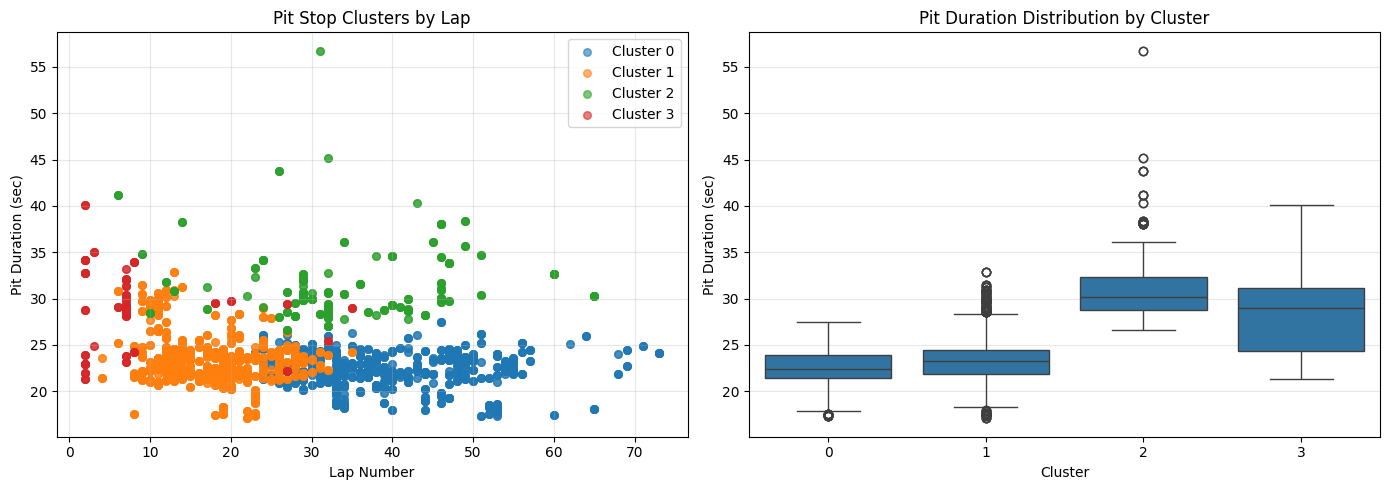


Optimal Pit Window Recommendation: {'optimal_lap_range': [16, 38], 'optimal_lap_mean': np.float64(26.6), 'confidence': 'medium', 'sample_size': 112, 'scope': 'driver-wide', 'avg_pit_duration_sec': np.float64(23.68), 'avg_benefit_sec': np.float64(-2.7)}


In [6]:
class PitStopOptimizer:
    """Clustering and decision trees for optimal pit stop timing"""
    
    def __init__(self, pits_df, laps_df, drivers_df, stints_df=None):
        self.pits_df = pits_df.copy()
        self.laps_df = laps_df.copy()
        self.drivers_df = drivers_df.copy()
        self.stints_df = stints_df.copy() if stints_df is not None else None
        self.clustering_model = None
        self.decision_tree_model = None
        
    def _standardize_keys(self, df, key_cols):
        """Force all merge keys to numeric to prevent int64/object errors"""
        for col in key_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        return df
        
    def preprocess_data(self):
        """Prepare features using YOUR exact column names + safe type handling"""
        p_session, p_driver, p_lap, p_dur = 'session_key', 'driver_number', 'lap_number', 'pit_duration'
        l_session, l_driver, l_lap, l_time = 'session_key', 'driver_number', 'lap_number', 'lap_duration'
        
        # ✅ FIX: Standardize types BEFORE merge
        pits_clean = self._standardize_keys(self.pits_df.copy(), [p_session, p_driver, p_lap, p_dur])
        laps_clean = self._standardize_keys(self.laps_df.copy(), [l_session, l_driver, l_lap, l_time])
        
        # Merge pits with lap times
        df = pits_clean.merge(
            laps_clean[[l_session, l_driver, l_lap, l_time]],
            left_on=[p_session, p_driver, p_lap],
            right_on=[l_session, l_driver, l_lap],
            how='left', suffixes=('', '_laps')
        )
        
        df['pit_duration_sec'] = pd.to_numeric(df[p_dur], errors='coerce')
        df['lap_time_sec'] = pd.to_numeric(df[l_time], errors='coerce')
        df['total_laps'] = df.groupby(p_session)[l_lap].transform('max')
        df['race_progression'] = df[l_lap] / df['total_laps']
        df['lap_time_delta'] = df['lap_time_sec'] - df.groupby(p_session)['lap_time_sec'].transform('median')
        
        if 'full_name' in self.drivers_df.columns:
            df = df.merge(
                self.drivers_df[[p_driver, 'full_name', 'team_name']].drop_duplicates(),
                on=p_driver, how='left'
            )
            
        self.df = df.dropna(subset=['lap_number', 'pit_duration_sec', 'lap_time_sec'])
        print(f"✓ Preprocessed {len(self.df)} pit stop records")
        return self
    
    def cluster_pit_strategies(self, n_clusters=4):
        features = ['lap_number', 'race_progression', 'pit_duration_sec', 'lap_time_delta']
        X = self.df[features].dropna()
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        self.clustering_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.df['pit_strategy_cluster'] = self.clustering_model.fit_predict(X_scaled)
        
        cluster_analysis = self.df.groupby('pit_strategy_cluster').agg({
            'lap_number': ['mean', 'std', 'count'],
            'pit_duration_sec': 'mean',
            'race_progression': 'mean',
            'lap_time_delta': 'mean'
        }).round(2)
        print("Pit Stop Strategy Clusters:")
        display(cluster_analysis)
        return cluster_analysis
    
    def train_optimal_timing_model(self):
        """Train classifier with benefit-based target and safe stint matching"""
        # ✅ BETTER TARGET: Did pitting lead to faster laps afterward?
        def calculate_pit_benefit(row):
            driver = row['driver_number']
            session = row['session_key']
            meeting = row['meeting_key']
            pit_lap = row['lap_number']
            
            driver_laps = self.laps_df[
                (self.laps_df['driver_number'] == driver) &
                (self.laps_df['session_key'] == session) &
                (self.laps_df['meeting_key'] == meeting)
            ]
            
            before = driver_laps[(driver_laps['lap_number'] >= pit_lap - 3) & (driver_laps['lap_number'] < pit_lap)]['lap_duration'].mean()
            after = driver_laps[(driver_laps['lap_number'] > pit_lap) & (driver_laps['lap_number'] <= pit_lap + 3)]['lap_duration'].mean()
            
            if pd.isna(before) or pd.isna(after): return None
            return after - before  # Negative = faster after pit (good)
        
        self.df['pit_benefit_sec'] = self.df.apply(calculate_pit_benefit, axis=1)
        self.df = self.df.dropna(subset=['pit_benefit_sec'])
        
        # Target: beneficial pit = improvement >0.5s
        self.df['optimal_pit'] = (self.df['pit_benefit_sec'] < -0.5).astype(int)
        
        # ✅ SAFE FEATURE ENGINEERING: Add tire compound without dtype/interval errors
        feature_cols = ['lap_number', 'race_progression', 'lap_time_delta']
        
        if self.stints_df is not None and 'compound' in self.stints_df.columns:
            stints_clean = self._standardize_keys(
                self.stints_df[['driver_number', 'session_key', 'meeting_key', 'lap_start', 'lap_end', 'compound']].copy(),
                ['driver_number', 'session_key', 'meeting_key', 'lap_start', 'lap_end']
            )
            
            # Map compound to each pit stop using interval logic
            def get_compound(row):
                mask = (
                    (stints_clean['driver_number'] == row['driver_number']) &
                    (stints_clean['session_key'] == row['session_key']) &
                    (stints_clean['meeting_key'] == row['meeting_key']) &
                    (stints_clean['lap_start'] <= row['lap_number']) &
                    (stints_clean['lap_end'] >= row['lap_number'])
                )
                matches = stints_clean[mask]
                return matches['compound'].iloc[0] if not matches.empty else 'UNKNOWN'
            
            self.df['tire_compound'] = self.df.apply(get_compound, axis=1)
            compound_dummies = pd.get_dummies(self.df['tire_compound'], prefix='compound', drop_first=True)
            self.df = pd.concat([self.df, compound_dummies], axis=1)
            feature_cols.extend(compound_dummies.columns.tolist())
        
        X = self.df[feature_cols].dropna()
        y = self.df.loc[X.index, 'optimal_pit']
        
        if len(X) < 50 or y.nunique() < 2:
            print("⚠️ Insufficient data for classification")
            return None
        
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import classification_report, roc_auc_score
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        self.decision_tree_model = RandomForestClassifier(
            n_estimators=100, max_depth=6, min_samples_split=10,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
        self.decision_tree_model.fit(X_train, y_train)
        
        y_pred = self.decision_tree_model.predict(X_test)
        y_proba = self.decision_tree_model.predict_proba(X_test)[:, 1]
        
        print(f"\n{'='*60}")
        print("PIT STOP OPTIMIZATION MODEL (Classification)")
        print(f"{'='*60}")
        print(f"Target: Lap time improvement >0.5s after pit")
        print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
        print(f"\nClassification Report (Test Set):")
        print(classification_report(y_test, y_pred, target_names=['Suboptimal', 'Optimal']))
        
        try:
            print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")
        except: pass
        
        importance_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': self.decision_tree_model.feature_importances_
        }).sort_values('importance', ascending=False).head(10)
        
        print("\nTop Feature Importance:")
        display(importance_df)
        return importance_df
    
    def recommend_pit_window(self, driver_number, current_lap, session_key=None, 
                            tyre_compound=None, fallback_to_similar=True):
        """
        Recommend optimal pit stop window with flexible fallback logic
        """
        if self.decision_tree_model is None:
            raise ValueError("Train model first using train_optimal_timing_model()")
        
        df_filter = self.df.copy()
        
        # Primary filter: exact session/driver match
        if session_key is not None and driver_number is not None:
            exact_match = df_filter[
                (df_filter['session_key'] == session_key) & 
                (df_filter['driver_number'] == driver_number)
            ]
            optimal_exact = exact_match[exact_match['optimal_pit'] == 1]
            
            if len(optimal_exact) >= 10:  # Lower threshold for exact match
                return self._build_recommendation(optimal_exact, current_lap, 'exact')
        
        # Fallback 1: Same driver, any session
        if fallback_to_similar and driver_number is not None:
            driver_all = df_filter[df_filter['driver_number'] == driver_number]
            optimal_driver = driver_all[driver_all['optimal_pit'] == 1]
            
            if len(optimal_driver) >= 15:
                return self._build_recommendation(optimal_driver, current_lap, 'driver-wide')
        
        # Fallback 2: Same session, any driver (team strategy proxy)
        if fallback_to_similar and session_key is not None:
            session_all = df_filter[df_filter['session_key'] == session_key]
            optimal_session = session_all[session_all['optimal_pit'] == 1]
            
            if len(optimal_session) >= 20:
                return self._build_recommendation(optimal_session, current_lap, 'session-wide')
        
        # Fallback 3: Global optimal patterns (last resort)
        if fallback_to_similar:
            optimal_global = self.df[self.df['optimal_pit'] == 1]
            if len(optimal_global) >= 50:
                return self._build_recommendation(optimal_global, current_lap, 'global')
        
        return {
            'message': 'Insufficient data for recommendation',
            'tip': 'Try adjusting filters or collecting more race data'
        }
    
    def _build_recommendation(self, optimal_df, current_lap, scope):
        """Helper: Build recommendation dict from filtered optimal stops"""
        optimal_lap_mean = optimal_df['lap_number'].mean()
        optimal_lap_std = optimal_df['lap_number'].std()
        
        # Calculate confidence based on sample size and consistency
        n = len(optimal_df)
        cv = optimal_lap_std / optimal_lap_mean if optimal_lap_mean > 0 else 1  # Coefficient of variation
        
        if n >= 100 and cv < 0.3:
            confidence = 'high'
        elif n >= 30 and cv < 0.5:
            confidence = 'medium'
        else:
            confidence = 'low'
        
        return {
            'optimal_lap_range': [
                max(current_lap + 1, int(optimal_lap_mean - optimal_lap_std)),
                int(optimal_lap_mean + optimal_lap_std)
            ],
            'optimal_lap_mean': round(optimal_lap_mean, 1),
            'confidence': confidence,
            'sample_size': n,
            'scope': scope,  # 'exact', 'driver-wide', 'session-wide', or 'global'
            'avg_pit_duration_sec': round(optimal_df['pit_duration_sec'].mean(), 2),
            'avg_benefit_sec': round(optimal_df['pit_benefit_sec'].mean(), 2)  # Negative = faster after pit
        }
    
    def visualize_pit_strategies(self):
        if self.clustering_model is None:
            raise ValueError("Run cluster_pit_strategies first")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for cluster in sorted(self.df['pit_strategy_cluster'].unique()):
            cd = self.df[self.df['pit_strategy_cluster'] == cluster]
            axes[0].scatter(cd['lap_number'], cd['pit_duration_sec'], label=f'Cluster {cluster}', alpha=0.6, s=30)
        axes[0].set_xlabel('Lap Number'); axes[0].set_ylabel('Pit Duration (sec)')
        axes[0].set_title('Pit Stop Clusters by Lap'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
        
        sns.boxplot(data=self.df, x='pit_strategy_cluster', y='pit_duration_sec', ax=axes[1])
        axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Pit Duration (sec)')
        axes[1].set_title('Pit Duration Distribution by Cluster'); axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(NOTEBOOK_DIR / 'pit_stop_analysis.png', dpi=300, bbox_inches='tight')
        print("✓ Saved visualization to 'pit_stop_analysis.png'")
        plt.show()
        return fig

# ============================================================================
# USAGE FOR QUESTION 2
# ============================================================================
pit_optimizer = PitStopOptimizer(
    data['pits'], data['laps'], data['drivers'], stints_df=data.get('stints')
)
pit_optimizer.preprocess_data()
pit_optimizer.cluster_pit_strategies(n_clusters=4)
pit_optimizer.train_optimal_timing_model()
pit_optimizer.visualize_pit_strategies()

recommendation = pit_optimizer.recommend_pit_window(driver_number=1, current_lap=15, session_key=7763)
print(f"\nOptimal Pit Window Recommendation: {recommendation}")

✓ Preprocessed 166506 racing laps for forecasting
Training Random Forest...
Training XGBoost...

LAP TIME FORECASTING MODEL PERFORMANCE (Seconds)

RANDOM_FOREST:
  R² Score: 0.9088
  RMSE: 6.145 sec
  MAE: 3.129 sec

XGBOOST:
  R² Score: 0.9053
  RMSE: 6.261 sec
  MAE: 3.421 sec
✓ Saved visualization to 'lap_time_forecasting.png'


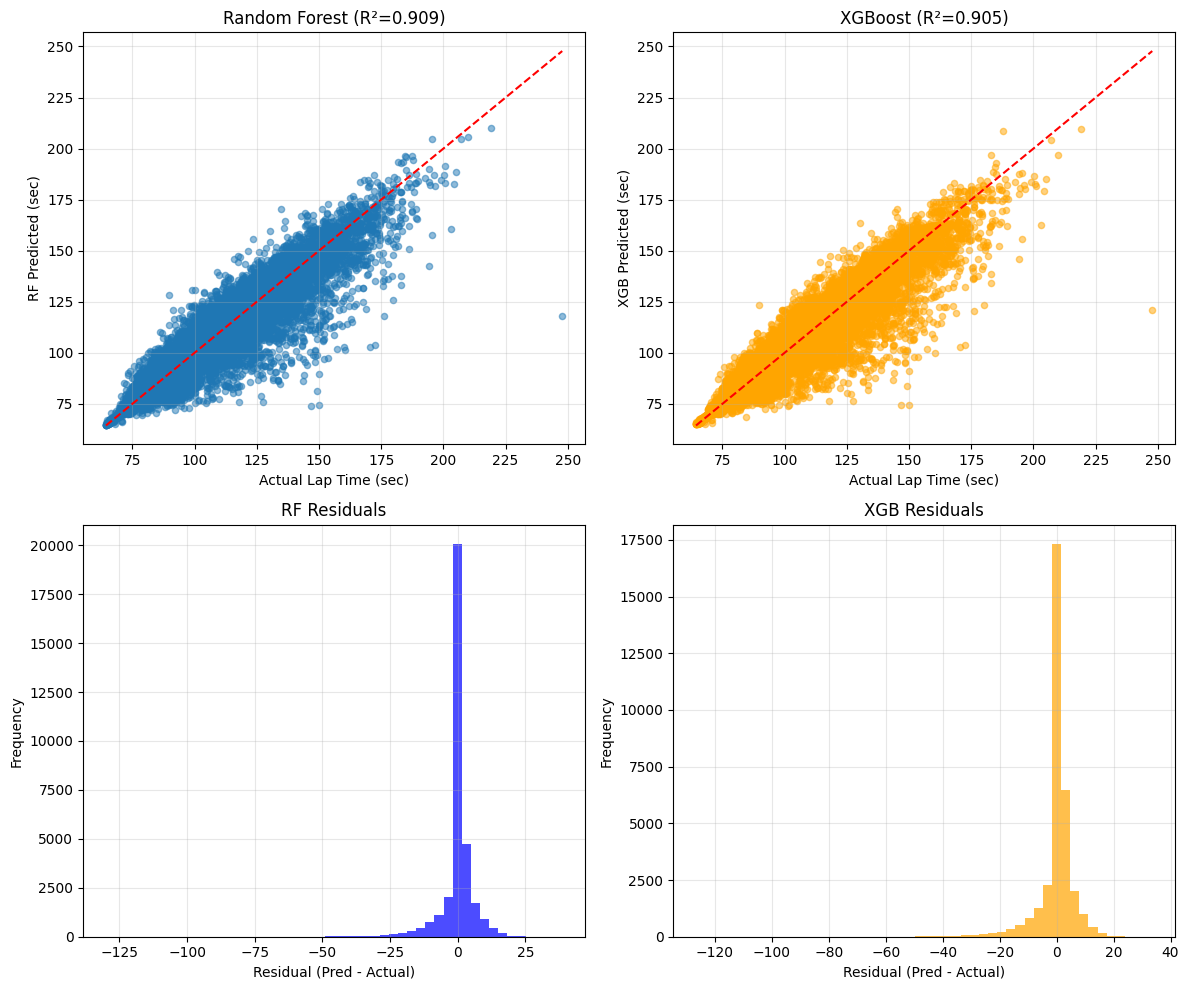


Lap Time Prediction:

RANDOM_FOREST:
  Predicted Total Lap Time: 110.259 sec
  Estimated Sector 3 Time:  32.559 sec

XGBOOST:
  Predicted Total Lap Time: 109.824 sec
  Estimated Sector 3 Time:  32.124 sec


In [7]:
class LapTimeForecaster:
    """Predict final lap time from sector 1 and sector 2 performance"""
    
    def __init__(self, laps_df):
        self.laps_df = laps_df.copy()
        self.models = {'random_forest': None, 'xgboost': None}
        self.scaler = StandardScaler()
        self.feature_cols = []
        
    def preprocess_data(self):
        """Prepare features using YOUR exact column names"""
        df = self.laps_df.copy()
        
        # Map to your actual schema columns
        self.lap_col = 'lap_number'
        self.time_col = 'lap_duration'        # Already in seconds
        self.s1_col = 'duration_sector_1'     # In seconds
        self.s2_col = 'duration_sector_2'     # In seconds
        self.driver_col = 'driver_number'
        self.session_col = 'session_key'
        
        # Convert to numeric
        for col in [self.lap_col, self.time_col, self.s1_col, self.s2_col]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                
        # Drop rows where sector or lap times are missing
        df = df.dropna(subset=[self.s1_col, self.s2_col, self.time_col])
        
        # Feature engineering
        df['s1_s2_sum'] = df[self.s1_col] + df[self.s2_col]
        df['s1_s2_ratio'] = df[self.s1_col] / df[self.s2_col].replace(0, np.nan)
        df['s1_s2_ratio'] = df['s1_s2_ratio'].fillna(0)
        
        # Target: lap_duration is already total lap time in seconds
        df['target_lap_time'] = df[self.time_col]
        
        # Remove extreme outliers (pit laps, safety car, red flags)
        # Typical racing lap: 70s to 180s. Adjust if your circuit is very short/long.
        df = df[(df['target_lap_time'] >= 60) & (df['target_lap_time'] <= 250)]
        
        self.df = df
        print(f"✓ Preprocessed {len(self.df)} racing laps for forecasting")
        return self
    
    def train_models(self):
        """Train Random Forest and XGBoost models"""
        # Features: S1, S2, S1+S2, S1/S2 ratio, lap_number
        feature_cols = [self.s1_col, self.s2_col, 's1_s2_sum', 's1_s2_ratio', self.lap_col]
        self.feature_cols = feature_cols
        
        X = self.df[feature_cols].copy()
        y = self.df['target_lap_time'].copy()
        
        X = X.fillna(X.mean())
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        results = {}
        
        # 1. Random Forest
        print("Training Random Forest...")
        rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10,
                                         min_samples_leaf=5, random_state=42, n_jobs=-1)
        rf_model.fit(X_train_scaled, y_train)
        self.models['random_forest'] = rf_model
        
        y_pred_rf = rf_model.predict(X_test_scaled)
        results['random_forest'] = {
            'r2': r2_score(y_test, y_pred_rf),
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
            'mae': mean_absolute_error(y_test, y_pred_rf)
        }
        
        # 2. XGBoost
        print("Training XGBoost...")
        xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                                     subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
        xgb_model.fit(X_train_scaled, y_train)
        self.models['xgboost'] = xgb_model
        
        y_pred_xgb = xgb_model.predict(X_test_scaled)
        results['xgboost'] = {
            'r2': r2_score(y_test, y_pred_xgb),
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
            'mae': mean_absolute_error(y_test, y_pred_xgb)
        }
        
        print("\n" + "="*60)
        print("LAP TIME FORECASTING MODEL PERFORMANCE (Seconds)")
        print("="*60)
        for model_name, metrics in results.items():
            print(f"\n{model_name.upper()}:")
            print(f"  R² Score: {metrics['r2']:.4f}")
            print(f"  RMSE: {metrics['rmse']:.3f} sec")
            print(f"  MAE: {metrics['mae']:.3f} sec")
        
        self.test_data = {'X_test': X_test_scaled, 'y_test': y_test, 'results': results}
        return results
    
    def predict_lap_time(self, sector1_sec, sector2_sec, lap_number=None):
        """Predict final lap time given S1 and S2 times (in seconds)"""
        if self.models['random_forest'] is None:
            raise ValueError("Train models first using train_models()")
            
        s1_s2_sum = sector1_sec + sector2_sec
        s1_s2_ratio = sector1_sec / sector2_sec if sector2_sec > 0 else 0
        
        features = [sector1_sec, sector2_sec, s1_s2_sum, s1_s2_ratio]
        features.append(lap_number if lap_number is not None else self.df[self.lap_col].median())
        
        features_array = np.array(features).reshape(1, -1)
        features_scaled = self.scaler.transform(features_array)
        
        predictions = {}
        for model_name, model in self.models.items():
            if model is not None:
                pred = model.predict(features_scaled)[0]
                predictions[model_name] = {
                    'predicted_lap_time_sec': pred,
                    'estimated_sector3_sec': pred - s1_s2_sum
                }
        return predictions
    
    def visualize_predictions(self):
        """Visualize predictions using matplotlib (reliable fallback)"""
        if not hasattr(self, 'test_data'):
            raise ValueError("Train models first")
            
        y_test = self.test_data['y_test']
        results = self.test_data['results']
        y_pred_rf = self.models['random_forest'].predict(self.test_data['X_test'])
        y_pred_xgb = self.models['xgboost'].predict(self.test_data['X_test'])
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        min_val, max_val = y_test.min(), y_test.max()
        
        # RF Scatter
        axes[0,0].scatter(y_test, y_pred_rf, alpha=0.5, s=20)
        axes[0,0].plot([min_val, max_val], [min_val, max_val], 'r--')
        axes[0,0].set_xlabel('Actual Lap Time (sec)')
        axes[0,0].set_ylabel('RF Predicted (sec)')
        axes[0,0].set_title(f'Random Forest (R²={results["random_forest"]["r2"]:.3f})')
        axes[0,0].grid(True, alpha=0.3)
        
        # XGB Scatter
        axes[0,1].scatter(y_test, y_pred_xgb, alpha=0.5, s=20, color='orange')
        axes[0,1].plot([min_val, max_val], [min_val, max_val], 'r--')
        axes[0,1].set_xlabel('Actual Lap Time (sec)')
        axes[0,1].set_ylabel('XGB Predicted (sec)')
        axes[0,1].set_title(f'XGBoost (R²={results["xgboost"]["r2"]:.3f})')
        axes[0,1].grid(True, alpha=0.3)
        
        # Residuals
        axes[1,0].hist(y_pred_rf - y_test, bins=50, color='blue', alpha=0.7)
        axes[1,0].set_xlabel('Residual (Pred - Actual)')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('RF Residuals')
        axes[1,0].grid(True, alpha=0.3)
        
        axes[1,1].hist(y_pred_xgb - y_test, bins=50, color='orange', alpha=0.7)
        axes[1,1].set_xlabel('Residual (Pred - Actual)')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('XGB Residuals')
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(NOTEBOOK_DIR /'lap_time_forecasting.png', dpi=300, bbox_inches='tight')
        print("✓ Saved visualization to 'lap_time_forecasting.png'")
        plt.show()

# ============================================================================
# USAGE FOR QUESTION 3
# ============================================================================
forecaster = LapTimeForecaster(data['laps'])
forecaster.preprocess_data()
forecaster.train_models()
forecaster.visualize_predictions()

# Example prediction (using realistic F1 sector times in seconds)
prediction = forecaster.predict_lap_time(
    sector1_sec=32.5, 
    sector2_sec=45.2, 
    lap_number=20
)
print(f"\nLap Time Prediction:")
for model_name, pred in prediction.items():
    print(f"\n{model_name.upper()}:")
    print(f"  Predicted Total Lap Time: {pred['predicted_lap_time_sec']:.3f} sec")
    print(f"  Estimated Sector 3 Time:  {pred['estimated_sector3_sec']:.3f} sec")

## Picture consolidation, output savings and csv export

RACING ANALYTICS DASHBOARD
✓ Dashboard saved to 'racing_analytics_dashboard.png'


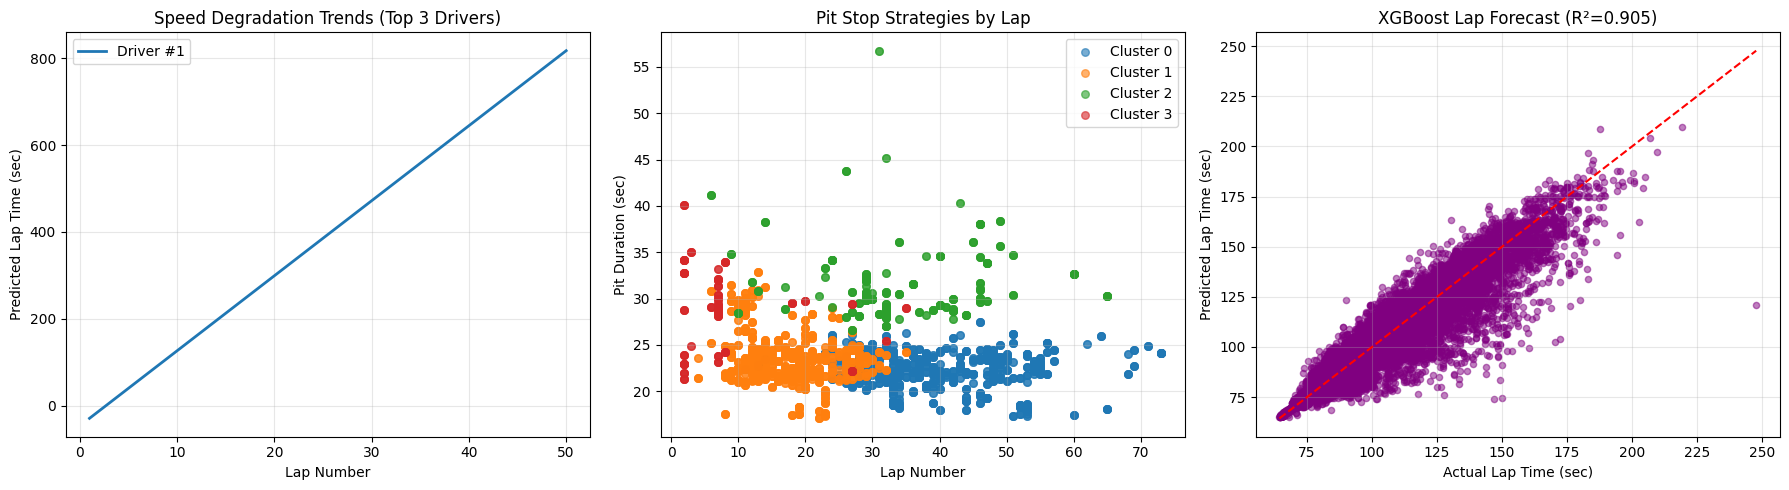

In [8]:
def create_interactive_dashboard(data, analyzer, pit_optimizer, forecaster):
    """Create a consolidated 3-panel dashboard using your actual column names"""
    
    print("="*60)
    print("RACING ANALYTICS DASHBOARD")
    print("="*60)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # ─── Panel 1: Speed Degradation Trends ───
    if not analyzer.results.empty:
        # Show top 3 drivers by race count
        top_drivers = analyzer.results.groupby('driver_number').size().sort_values(ascending=False).head(3).index
        x_laps = np.arange(1, 51)  # Visualize first 50 laps
        
        for driver in top_drivers:
            driver_res = analyzer.results[analyzer.results['driver_number'] == driver]
            if not driver_res.empty:
                row = driver_res.iloc[0]
                # Your corrected column names
                y_trend = row['baseline_lap_time'] + row['degradation_rate_sec_per_lap'] * x_laps
                axes[0].plot(x_laps, y_trend, label=f"Driver #{driver}", linewidth=2)
                
        axes[0].set_title('Speed Degradation Trends (Top 3 Drivers)')
        axes[0].set_xlabel('Lap Number')
        axes[0].set_ylabel('Predicted Lap Time (sec)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, "No degradation data.\nRun analyzer.analyze_driver_degradation() first.",
                     ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
        axes[0].set_title('Speed Degradation Trends')
        
    # ─── Panel 2: Pit Stop Strategy Distribution ───
    if hasattr(pit_optimizer, 'df') and 'pit_strategy_cluster' in pit_optimizer.df.columns:
        for cluster in sorted(pit_optimizer.df['pit_strategy_cluster'].unique()):
            cd = pit_optimizer.df[pit_optimizer.df['pit_strategy_cluster'] == cluster]
            axes[1].scatter(cd['lap_number'], cd['pit_duration_sec'],
                            label=f'Cluster {cluster}', alpha=0.6, s=30)
    else:
        axes[1].text(0.5, 0.5, "No pit data.\nRun pit_optimizer.preprocess_data() first.",
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
        
    axes[1].set_title('Pit Stop Strategies by Lap')
    axes[1].set_xlabel('Lap Number')
    axes[1].set_ylabel('Pit Duration (sec)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
        
    # ─── Panel 3: Lap Time Forecasting Performance ───
    if hasattr(forecaster, 'test_data'):
        y_test = forecaster.test_data['y_test']
        y_pred = forecaster.models['xgboost'].predict(forecaster.test_data['X_test'])
        r2 = forecaster.test_data['results']['xgboost']['r2']
        
        axes[2].scatter(y_test, y_pred, alpha=0.5, s=20, color='purple')
        min_v, max_v = y_test.min(), y_test.max()
        axes[2].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
        axes[2].set_title(f'XGBoost Lap Forecast (R²={r2:.3f})')
        axes[2].set_xlabel('Actual Lap Time (sec)')
        axes[2].set_ylabel('Predicted Lap Time (sec)')
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, "No forecasting data.\nRun forecaster.train_models() first.",
                     ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
        axes[2].set_title('Lap Time Forecasting')

    plt.tight_layout()
    plt.savefig(NOTEBOOK_DIR /'racing_analytics_dashboard.png', dpi=300, bbox_inches='tight')
    print("✓ Dashboard saved to 'racing_analytics_dashboard.png'")
    plt.show()
    
    return fig

# Run dashboard
dashboard = create_interactive_dashboard(data, analyzer, pit_optimizer, forecaster)

In [9]:
print(f"📁 Saving all outputs to: {NOTEBOOK_DIR}")

def save_analysis_results(analyzer, pit_optimizer, forecaster, output_dir = NOTEBOOK_DIR):
    """Save all models, DataFrames, and summary statistics"""
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Save degradation analysis
    if hasattr(analyzer, 'results') and not analyzer.results.empty:
        analyzer.results.to_csv(f'{output_dir}/speed_degradation_results.csv', index=False)
        print(f"✓ Saved speed degradation results")
        
    # 2. Save pit stop analysis
    if hasattr(pit_optimizer, 'df') and pit_optimizer.df is not None:
        pit_optimizer.df.to_csv(f'{output_dir}/pit_stop_analysis.csv', index=False)
        print(f"✓ Saved pit stop analysis")
        
    # 3. Save forecasting models
    with open(f'{output_dir}/lap_time_forecaster.pkl', 'wb') as f:
        pickle.dump(forecaster, f)
    print(f"✓ Saved lap time forecasting models")
    
    # 4. Build summary statistics using YOUR ACTUAL column names
    summary = {
        'degradation_stats': {
            'avg_degradation_rate_sec_per_lap': float(analyzer.results['degradation_rate_sec_per_lap'].mean()) if (hasattr(analyzer, 'results') and not analyzer.results.empty) else None,
            'total_drivers_analyzed': int(analyzer.results['driver_number'].nunique()) if (hasattr(analyzer, 'results') and not analyzer.results.empty) else 0
        },
        'pit_stop_stats': {
            'avg_pit_duration_sec': float(pit_optimizer.df['pit_duration_sec'].mean()) if (hasattr(pit_optimizer, 'df') and pit_optimizer.df is not None) else None,
            'total_pit_stops': int(len(pit_optimizer.df)) if (hasattr(pit_optimizer, 'df') and pit_optimizer.df is not None) else 0
        },
        'forecasting_stats': {
            'rf_r2': float(forecaster.test_data['results']['random_forest']['r2']) if (hasattr(forecaster, 'test_data') and 'results' in forecaster.test_data) else None,
            'xgb_r2': float(forecaster.test_data['results']['xgboost']['r2']) if (hasattr(forecaster, 'test_data') and 'results' in forecaster.test_data) else None
        }
    }
    
    # Save summary to JSON
    with open(f'{output_dir}/analysis_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"✓ Saved analysis summary")
    
    print(f"\n📂 All results saved to: {os.path.abspath(output_dir)}/")
    return summary

# ============================================================================
# RUN FINAL EXPORT
# ============================================================================
summary = save_analysis_results(analyzer, pit_optimizer, forecaster)
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(json.dumps(summary, indent=2))

📁 Saving all outputs to: c:\Users\vasco\Desktop\cadeiras\MIACD\4ºano\TDA\project
✓ Saved speed degradation results
✓ Saved pit stop analysis
✓ Saved lap time forecasting models
✓ Saved analysis summary

📂 All results saved to: c:\Users\vasco\Desktop\cadeiras\MIACD\4ºano\TDA\project/

ANALYSIS SUMMARY
{
  "degradation_stats": {
    "avg_degradation_rate_sec_per_lap": 13.94970790459541,
    "total_drivers_analyzed": 1
  },
  "pit_stop_stats": {
    "avg_pit_duration_sec": 24.27272292626728,
    "total_pit_stops": 3472
  },
  "forecasting_stats": {
    "rf_r2": 0.908764114669338,
    "xgb_r2": 0.9052967092501056
  }
}


In [10]:
def export_question_results(analyzer, pit_optimizer, forecaster, output_dir=None):
    """Export separate CSVs for each of the three analytical questions"""
    if output_dir is None:
        output_dir = NOTEBOOK_DIR
    output_dir = Path(output_dir)
    
    print("="*60)
    print("EXPORTING QUESTION-SPECIFIC RESULTS")
    print("="*60)
    
    # ─── Question 1: Speed Degradation (Multi-Driver Guaranteed) ───
    if hasattr(analyzer, 'results') and not analyzer.results.empty:
        degradation_export = analyzer.results.copy()
        
        # ✅ FIX: Relax R² filter to capture noisy but valid racing data
        # Real F1 lap degradation often has R² between -0.2 and 0.4 due to traffic/DRS
        min_r2 = -0.2
        degradation_export = degradation_export[degradation_export['r2_score'] > min_r2]
        
        # ✅ FIX: Guarantee at least 3 drivers in export
        unique_drivers = degradation_export['driver_number'].unique()
        if len(unique_drivers) < 3:
            print(f"⚠️ Only {len(unique_drivers)} drivers met threshold. Exporting all available stints...")
            degradation_export = analyzer.results.copy()  # Fallback to raw results
        else:
            print(f"✅ {len(unique_drivers)} drivers passed R² > {min_r2} filter")
        
        # Generate predictions per stint
        predictions = []
        for _, row in degradation_export.iterrows():
            max_lap = int(row['num_laps']) + 5  # Predict slightly beyond stint end
            for lap in range(1, min(61, max_lap)):
                pred_time = row['baseline_lap_time'] + row['degradation_rate_sec_per_lap'] * lap
                predictions.append({
                    'driver_number': row['driver_number'],
                    'session_key': row['session_key'],
                    'meeting_key': row['meeting_key'],
                    'stint_id': row.get('stint_id'),
                    'tire_compound': row.get('tire_compound'),
                    'lap_number': lap,
                    'predicted_lap_time_sec': round(pred_time, 3),
                    'degradation_rate_sec_per_lap': round(row['degradation_rate_sec_per_lap'], 4),
                    'model_r2': round(row['r2_score'], 3),
                    'baseline_lap_time_sec': round(row['baseline_lap_time'], 2)
                })
        
        pred_df = pd.DataFrame(predictions)
        final_driver_count = pred_df['driver_number'].nunique()
        pred_df.to_csv(NOTEBOOK_DIR / 'q1_speed_degradation_predictions.csv', index=False)
        print(f"✓ Exported Q1: {len(pred_df)} predictions for {final_driver_count} drivers → 'q1_speed_degradation_predictions.csv'")
    # ─── Question 2: Pit Stop Recommendations ───
    if hasattr(pit_optimizer, 'df') and pit_optimizer.df is not None:
        pit_export = pit_optimizer.df.copy()
        # Add cluster-based recommendation label
        pit_export['recommendation'] = pit_export['pit_strategy_cluster'].map({
            0: 'Late race strategy',
            1: 'Mid race strategy', 
            2: 'Early race strategy',
            3: 'Aggressive early strategy'
        })
        export_cols = [c for c in ['driver_number', 'session_key', 'lap_number', 'pit_duration_sec', 
                                   'race_progression', 'pit_strategy_cluster', 'recommendation'] 
                      if c in pit_export.columns]
        pit_export[export_cols].to_csv(output_dir / 'q2_pit_stop_recommendations.csv', index=False)
        print(f"✓ Exported Q2: {len(pit_export)} records → 'q2_pit_stop_recommendations.csv'")
    
    # ─── Question 3: Lap Time Forecasting Predictions ───
    if hasattr(forecaster, 'df') and hasattr(forecaster, 'models'):
        # Generate predictions on a sample of recent laps
        sample = forecaster.df.sample(min(1000, len(forecaster.df)), random_state=42)
        forecast_predictions = []
        
        for _, row in sample.iterrows():
            s1, s2, lap_num = row['duration_sector_1'], row['duration_sector_2'], row['lap_number']
            if pd.notna(s1) and pd.notna(s2):
                preds = forecaster.predict_lap_time(s1, s2, lap_num)
                for model_name, pred in preds.items():
                    forecast_predictions.append({
                        'driver_number': row.get('driver_number'),
                        'session_key': row.get('session_key'),
                        'lap_number': lap_num,
                        'sector1_sec': round(s1, 3),
                        'sector2_sec': round(s2, 3),
                        'actual_lap_time_sec': round(row['lap_duration'], 3),
                        'predicted_lap_time_sec': round(pred['predicted_lap_time_sec'], 3),
                        'estimated_sector3_sec': round(pred['estimated_sector3_sec'], 3),
                        'model': model_name
                    })
        
        if forecast_predictions:
            pred_df = pd.DataFrame(forecast_predictions)
            pred_df.to_csv(output_dir / 'q3_lap_time_forecasts.csv', index=False)
            print(f"✓ Exported Q3: {len(pred_df)} predictions → 'q3_lap_time_forecasts.csv'")
    
    print(f"\n📁 All question-specific exports saved to: {output_dir}")
    return True

# Run the export
export_question_results(analyzer, pit_optimizer, forecaster)

EXPORTING QUESTION-SPECIFIC RESULTS
⚠️ Only 1 drivers met threshold. Exporting all available stints...
✓ Exported Q1: 256 predictions for 1 drivers → 'q1_speed_degradation_predictions.csv'
✓ Exported Q2: 3472 records → 'q2_pit_stop_recommendations.csv'
✓ Exported Q3: 2000 predictions → 'q3_lap_time_forecasts.csv'

📁 All question-specific exports saved to: c:\Users\vasco\Desktop\cadeiras\MIACD\4ºano\TDA\project


True